In [1]:
# Import modules

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read freqency data

df = pd.read_csv(
    'ngram_freq.csv',
    header=0,
    names=['word', 'count'],
    keep_default_na=False,
    dtype={'word': str, 'count': 'int64'}
)

In [3]:
# Clean data

alphabet = set("abcdefghijklmnopqrstuvwxyz")
def clean_words(word):
    word = word.lower()
    is_alpha = True
    for char in word:
        if char not in alphabet:
            is_alpha = False
            break
    return word if is_alpha else np.nan

df['word'] = df['word'].apply(clean_words)

count_removed = df['word'].isna().sum()

df = df.dropna(subset=['word'])

print(f"Removed {count_removed} non-alpha words")

Removed 230973 non-alpha words


In [4]:
# Load Scrabble word lists and mark words in dataframe

scrabble_words = set()
word_lists = ["word_lists/1_NSWL2023.txt","word_lists/2_sowpods.txt"]

for word_list in word_lists:
    with open(word_list, 'r') as f:
        for line in f:
            scrabble_words.add(line.strip().lower())

df['is_scrabble'] = df['word'].apply(lambda x: 1 if x in scrabble_words else 0)

In [5]:
# Print Summary statistics

print(f"Total words: {len(df)}")
print(f"Total Scrabble words: {df['is_scrabble'].sum()}")
print(f"Size of dataframe: {df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")
print(f"Percentage of words in frequency data that are Scrabble words: {df['is_scrabble'].mean() * 100:.2f}%")
print(f"Percentage of Scrabble words that appear in frequency data: {df['is_scrabble'].sum() / len(scrabble_words) * 100:.2f}%")

Total words: 9013906
Total Scrabble words: 241293
Size of dataframe: 702.10 MB
Percentage of words in frequency data that are Scrabble words: 2.68%
Percentage of Scrabble words that appear in frequency data: 88.25%


In [6]:
# Boost Scrabble words in scoring

# The goal is to create a scoring system that ranks words based on their frequency and whether they are valid Scrabble words.
# We want to ensure that valid Scrabble words are prioritized, but we also want to consider the frequency of the words.

from sklearn.metrics import roc_auc_score

# First create a score by boosting the frequency counts of Scrabble words
multiplier = 100
df['score'] = df['count'] * (1 + multiplier * df['is_scrabble'])

df = df.sort_values(by=['score', 'word'], ascending=[False, True]).reset_index(drop=True)

# Check the AUC-ROC score to evaluate discrimination
# Checks to see how well the 'score' separates Scrabble words from non-Scrabble words
X_score = df['score']
Y_scrabble = df['is_scrabble']
auc_roc = roc_auc_score(Y_scrabble, X_score)

# An AUC above 0.95 is generally considered excellent discrimination.
print(f"Area Under ROC Curve (AUC): {auc_roc:.4f}")

Area Under ROC Curve (AUC): 0.9953


In [ ]:
# # Attempt to find close matches for Scrabble words not in the frequency data
# # using an optimized fuzzy matching approach with RapidFuzz
# # Skipping this step for now as it is slow and not critical to the main analysis
# # Also word similarity does not seem to correlate well with frequency

# # Find Scrabble words not in frequency data

# df_word_set = set(df['word'])
# scrabble_words_not_in_df = [word for word in scrabble_words if word not in df_word_set]
# print(f"Number of Scrabble words not in frequency data: {len(scrabble_words_not_in_df)}")
# print(f"Some examples of Scrabble words not in frequency data: {scrabble_words_not_in_df[:10]}")

# from rapidfuzz import process, fuzz
# import collections

# search_list = list(df['word'].head(10_000))

# length_to_words = collections.defaultdict(list)
# for word in search_list:
#     length_to_words[len(word)].append(word)

# def get_candidates_and_match_optimized(query_word, length_map, max_diff=2):
#     """
#     Finds the single best fuzzy match by quickly indexing candidates by length,
#     then running RapidFuzz only on those candidates.
#     """
#     query_len = len(query_word)
#     candidate_list = []
    
#     # 1. Fast Candidate Collection (O(1) lookups in the hash map)
#     # Check lengths: query_len, query_len-1, query_len+1, etc.
#     for length_diff in range(-max_diff, max_diff + 1):
#         length = query_len + length_diff
#         if length in length_map:
#             candidate_list.extend(length_map[length])
            
#     if not candidate_list:
#         return None
    
#     # 2. Optimized Matching on the candidates
#     return process.extractOne(
#         query_word, 
#         candidate_list, 
#         scorer=fuzz.ratio, 
#         score_cutoff=90
#     )
    
# scrabble_words_not_in_df_with_matches = {}

# match_count = 0
# # Use a generator expression for memory efficiency and process the results
# for i, word in enumerate(scrabble_words_not_in_df, 1):
#     match = get_candidates_and_match_optimized(word, length_to_words)

#     if match:
#         scrabble_words_not_in_df_with_matches[word] = match
#         match_count += 1
    
#     if i % 1000 == 0:
#         print(f"Processed {i} words. Found {match_count} matches.")

# print(f"Total matches found: {len(scrabble_words_not_in_df_with_matches)} out of {len(scrabble_words_not_in_df)}")
# for word, match in scrabble_words_not_in_df_with_matches.items():
#     print(f"{word} -> {match[0]} (Score: {match[1]})")

In [7]:
# Apply logarithm transform and normalize scores

# According to Zipf's law, word frequencies often follow a power-law distribution.
# To better model this, we can use a logarithmic transformation of the scores.
# Then we normalize the scores to a 0-1 range for easier interpretation.

df['log_score'] = np.log(df['score'])

min_val = df['log_score'].min()
max_val = df['log_score'].max()

df["normalized_score"] = ((df['log_score'] - min_val) / (max_val - min_val))

print(df[['word', 'count', 'normalized_score', 'is_scrabble']])

              word         count  normalized_score  is_scrabble
0              the  125971793511          1.000000            1
1               of   77466218166          0.981642            1
2              and   55607010885          0.969125            1
3               to   46622823631          0.962471            1
4               in   40069476427          0.956752            1
...            ...           ...               ...          ...
9013901   zvrittcn            40          0.000000            0
9013902  zweifelst            40          0.000000            0
9013903       zwmo            40          0.000000            0
9013904  zworkykin            40          0.000000            0
9013905       zzof            40          0.000000            0

[9013906 rows x 4 columns]


In [9]:
# Fit a sigmoid function to the normalized scores

# Next, we will fit a sigmoid function to the normalized scores to create a smooth scoring curve.
# The goal is to create a function that assigns high scores to Scrabble words and low scores to non-Scrabble words.
# But the function is used to estimate scores for all words based on their frequency score.

from scipy.optimize import curve_fit

# Extracting the feature (X) and the target (Y) from your DataFrame
# Replace 'words_df' with the actual name of your pandas DataFrame
X = df['normalized_score'].values
# Convert boolean to integer target scores (True -> 1, False -> 0)
Y = df['is_scrabble'].values

# The sigmoid function definition (must take X first, then parameters k, x0)
def sigmoid_score(X, k, x0):
    """
    The function to be fitted: 1 / (1 + exp(-k * (X - x0)))
    k: steepness (gain)
    x0: threshold (midpoint)
    """
    return 1 / (1 + np.exp(-k * (X - x0)))

# --- Run the Curve Fitting ---

# Initial guess for parameters: [k, x0]
# 12 and 0.5 are good starting points, but you can be less precise.
initial_guess = [10.0, 0.5]

# Set bounds: k must be positive and x0 must be between 0 and 1 (since X is normalized).
# We set a high max for k (100) and keep x0 within the 0 to 1 range.
bounds = ([1.0, 0.01], [100.0, 0.99])

popt, pcov = curve_fit(
    sigmoid_score,
    X,
    Y,
    p0=initial_guess,
    bounds=bounds
)

optimized_k, optimized_x0 = popt

print("--- Optimization Complete ---")
print(f"Optimal Steepness (k): {optimized_k:.3f}")
print(f"Optimal Threshold (x0): {optimized_x0:.3f}")

# --- Final Score Function ---
def final_score(x):
    return 1 / (1 + np.exp(-optimized_k * (x - optimized_x0)))

# Apply the final score back to your DataFrame
df['final_score'] = df['normalized_score'].apply(final_score)

--- Optimization Complete ---
Optimal Steepness (k): 27.458
Optimal Threshold (x0): 0.333


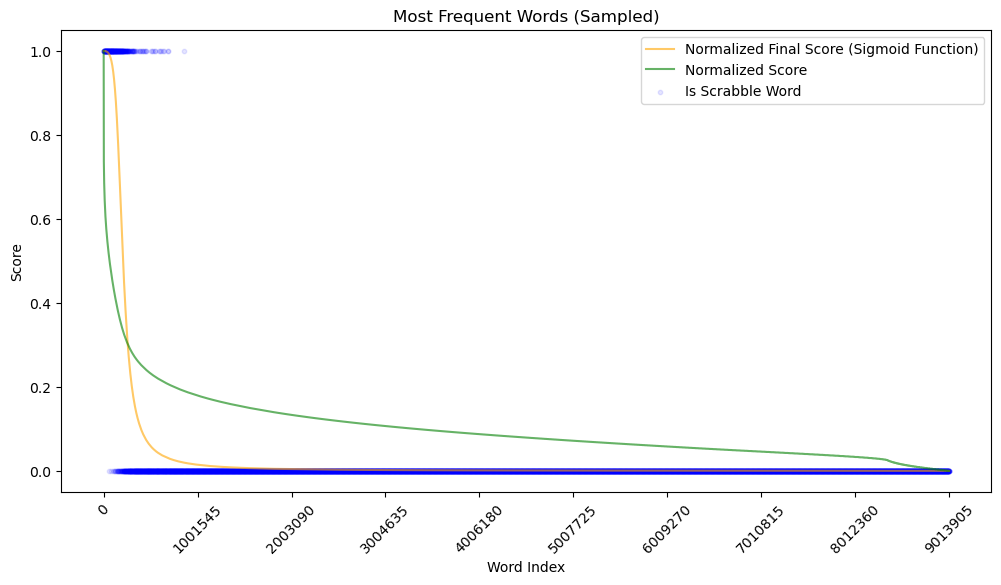

In [10]:
# Display the final scores

sample_size = 10000
max = len(df) - 1
sample_indices = np.linspace(0, max, sample_size, dtype=int)
plt.figure(figsize=(12, 6))
plt.plot(sample_indices, df['final_score'].iloc[sample_indices], label='Normalized Final Score (Sigmoid Function)', color='orange', alpha=0.6)
plt.plot(sample_indices, df['normalized_score'].iloc[sample_indices], label='Normalized Score', color='green', alpha=0.6)
plt.scatter(sample_indices, df['is_scrabble'].iloc[sample_indices], label='Is Scrabble Word', color='blue', alpha=0.1, s=10)
plt.xticks(np.linspace(0, max, 10, dtype=int), np.linspace(0, max, 10, dtype=int), rotation=45)
plt.xlabel('Word Index')
plt.ylabel('Score')
plt.title('Most Frequent Words (Sampled)')
plt.legend()
plt.show()


100% of Scrabble words with frequency are found by index 1079700


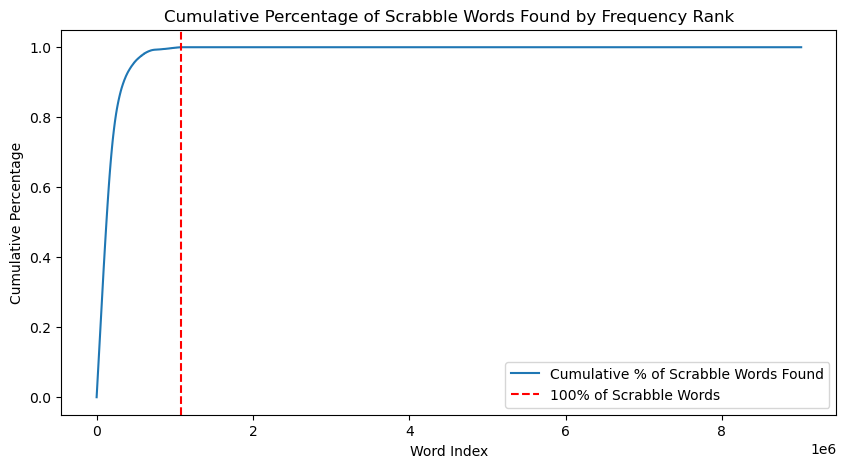

In [11]:
# Plot cumulative percentage of Scrabble words found
# Ideally we want to find a large percentage of Scrabble words in the top N words

total_scrabble = df['is_scrabble'].sum()
cumulative_scrabble_in_df = df['is_scrabble'].cumsum() / total_scrabble

target_percentage = 1
cross_indices = cumulative_scrabble_in_df[cumulative_scrabble_in_df >= target_percentage].index
cross_idx = cross_indices[0]

print(f"{target_percentage * 100}% of Scrabble words with frequency are found by index {cross_idx}")

plt.figure(figsize=(10, 5))
plt.plot(cumulative_scrabble_in_df, label='Cumulative % of Scrabble Words Found')
plt.xlabel('Word Index')
plt.ylabel('Cumulative Percentage')
plt.title('Cumulative Percentage of Scrabble Words Found by Frequency Rank')
plt.axvline(x=cross_idx, color='r', linestyle='--', label=f'{target_percentage*100}% of Scrabble Words')
plt.legend(loc = 'lower right')
plt.show()

In [12]:
# Get score of the word at index n and find last index with that score
# This way words with the same score as the n-th word are all included

last_idx = cross_idx

score_n = df.iloc[last_idx]['final_score']
print(f"Score of the word at index {last_idx} ('{df.iloc[last_idx]['word']}'): {score_n:.6f}")

last_idx = df[df['final_score'] == score_n].index[-1]
n = last_idx + 1
print(f"Last index with score {score_n:.6f}: {last_idx} ('{df.iloc[last_idx]['word']}')")

print(f"Memory usage of the first {n} rows: {df[['word', 'is_scrabble', 'final_score']].head(n).memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Score of the word at index 1079700 ('wormils'): 0.012732
Last index with score 0.012732: 1079702 ('zazous')
Memory usage of the first 1079703 rows: 75.12 MB


In [13]:
# Save scores to a CSV file

output_df = df[['word', 'is_scrabble', 'final_score']]
output_df.to_csv(
    'word_scores.csv', 
    index=False, # This prevents Pandas from writing the DataFrame index as a column
    header=True  # This ensures the column names ('word', 'final_score') are written as the header
)